# Overview {#sec-pose2sim}

In the [previous script](../02_MotionTracking_processing/02_Track_OpenPose.ipynb#sec-openpose), we have extracted 2D keypoints for each trial (per each video, 3 in total). In this script, we will use Pose2sim [@pagnon_etal22] to calibrate the 3 cameras present in the lab setup, and triangulate the 3D position of the keypoints.

Demo of this pipeline has been published on [EnvisionBOX](https://www.envisionbox.org/embedded_openpose_to_pose2sim_tracking.html)

While in preregistration we used *version 0.10.6*, the final processing uses *version FILL-IN*. The new version allows one to also perform inverse kinematics (i.e., joint angles) using OpenSim API [@seth_etal18]. As it improves and simplifies the process and the scripting workflow, we deem this a legitimate deviation from the previous script. 

For more information on Pose2sim, please refer to the [Pose2sim documentation](https://github.com/perfanalytics/pose2sim)

Lastly, using OpenSim [@seth_etal18], we finish the workflow with calculating inverse dynamics (i.e., joint forces). In the preregistration, this was done in a separate script but given that we moved the inverse kinematics here, we perform the inverse dynamics here as well.

The documentation of OpenSim project is available [here](https://opensimconfluence.atlassian.net/wiki/spaces/OpenSim/overview)


In [ ]:
#| code-fold: true
#| code-summary: Code to prepare the environment

from Pose2Sim import Pose2Sim
import os
import glob
import pandas as pd
from trc import TRCData
import pandas as pd
import shutil
import cv2
import numpy as np
import toml
import matplotlib.pyplot as plt

curfolder = os.getcwd()
print('Current folder is: ' + curfolder)

# Here is our config.file
pose2simprjfolder = os.path.join(curfolder, 'Pose2Sim', 'FLESH_setup')

# Here we store the data
inputfolder = os.path.join(curfolder, 'projectdata')
folderstotrack = glob.glob(os.path.join(inputfolder, '*'))
#print(folderstotrack)

# Here we store mass information (weight, height) about participants
META = pd.read_csv(os.path.join(curfolder, '..', '00_raw', 'all_demodata.csv')) 

# Initiate empty list
pcnfolders = []

# Get all the folders per session, per participant
for i in folderstotrack:
    pcn1folders = glob.glob(os.path.join(i, '*'))
    pcn2folders = glob.glob(os.path.join(i, '*'))
    pcnfolders_in_session = pcn1folders + pcn2folders
    pcnfolders = pcnfolders + pcnfolders_in_session


# Get rid of all pontetially confusing files/folders
pcnfolders = [x for x in pcnfolders if 'Config' not in x]
pcnfolders = [x for x in pcnfolders if 'opensim' not in x]
pcnfolders = [x for x in pcnfolders if 'xml' not in x]
pcnfolders = [x for x in pcnfolders if 'ResultsInverseDynamics' not in x]
pcnfolders = [x for x in pcnfolders if 'ResultsInverseKinematics' not in x]
pcnfolders = [x for x in pcnfolders if 'sto' not in x]
pcnfolders = [x for x in pcnfolders if 'txt' not in x]
pcnfolders = [x for x in pcnfolders if 'calibration' not in x]
print(pcnfolders[0:10])


# Prepare special log txt
error_log = os.path.join(curfolder, 'errors', 'pose2sim_error_log.txt')
if not os.path.exists(error_log):
    with open(error_log, 'w') as f:
        f.write('Pose2Sim processing error log\n')
        f.write('============================\n\n')

Current folder is: f:\flesh_data_processed\02_MotionTracking_processing
['f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_11_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_12_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_13_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_14_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_15_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_16_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_17_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_20_p0', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_21_p0', 'f:\\flesh_data_processed\\02_MotionTracking_processin

In [ ]:
#| code-fold: true
#| code-summary: Custom functions

import copy
import logging
import traceback

def load_toml(file_path):
    """
    Loads a TOML file and returns its contents as a dictionary.

    Args:
        file_path (str): Path to the TOML file to be loaded.

    Returns:
        dict: The contents of the TOML file as a dictionary.
    """
    with open(file_path, 'r') as file:
        return toml.load(file)

def save_toml(data, file_path):
    """
    Saves a dictionary to a TOML file.

    Args:
        data (dict): The dictionary to be saved as a TOML file.
        file_path (str): Path to the TOML file to be created or overwritten.
    """
    with open(file_path, 'w') as file:
        toml.dump(data, file)

def update_participant_info(toml_data, height, mass):
    """
    Updates the participant information in the TOML data with the given height and mass.

    Args:
        toml_data (dict): The TOML data to be updated.
        height (float): The height of the participant.
        mass (float): The mass of the participant.

    Returns:
        dict: The updated TOML data with the new participant information.
    """

    # Make copy of toml data
    toml_data_new = copy.deepcopy(toml_data)
    if 'project' in toml_data:
        toml_data_new['project']['participant_height'] = height
        toml_data_new['project']['participant_mass'] = mass
        toml_data_new['kinematics']['default_height'] = height
    else:
        raise KeyError("The key 'project' is not present in the TOML data.")
    return toml_data_new

def update_framerate(toml_data, framerate):
    """
    Updates the frame rate in the TOML data with the given value.

    Args:
        toml_data (dict): The TOML data to be updated.
        framerate (float): The new frame rate to be set.

    Returns:
        dict: The updated TOML data with the new frame rate.
    """

    # Make copy of toml data
    toml_data_new = copy.deepcopy(toml_data)
    if 'project' in toml_data:
        toml_data_new['project']['frame_rate'] = framerate
    else:
        raise KeyError("The key 'project' is not present in the TOML data.")
    return toml_data_new

#| code-fold: true
#| code-summary: Code to prepare the environment

def select_and_save_frame_every_x(video_paths, output_dirs, x_interval=3):
    """
    Display every x-th frame from camera 1, let the user choose one to save,
    and save that same frame index from camera 2 and 3 into their respective output_dirs.

    Args:
        video_paths (list): List of paths to the three videos (cam1, cam2, cam3).
        output_dirs (list): List of output directories for the three cameras.
        x_interval (int): Interval to skip frames (every x-th frame is displayed).
    """
    assert len(video_paths) == 3 and len(output_dirs) == 3, "Expect 3 videos and 3 output folders (cam1, cam2, cam3)"
    
    # Read first video to choose frame
    cap1 = cv2.VideoCapture(video_paths[0])
    frame_index = 0
    selected_index = None

    while True:
        ret = cap1.grab()  # Skip non-x frames
        if not ret:
            break

        if frame_index % x_interval == 0:
            ret, frame = cap1.retrieve()
            if not ret:
                break

            cv2.imshow('Select Frame - Press s to save, n to skip', frame)
            key = cv2.waitKey(0)

            if key == ord('s'):
                selected_index = frame_index
                print(f'Selected frame: {selected_index}')
                break
            elif key == ord('q'):
                print('Quitting selection')
                break

        frame_index += 1

    cap1.release()
    cv2.destroyAllWindows()

    if selected_index is not None:
        for cam_index, (video_path, output_dir) in enumerate(zip(video_paths, output_dirs)):
            cap = cv2.VideoCapture(video_path)
            cap.set(cv2.CAP_PROP_POS_FRAMES, selected_index)
            ret, frame = cap.read()
            if ret:
                os.makedirs(output_dir, exist_ok=True)
                save_path = os.path.join(output_dir, f'selected_frame.png')
                cv2.imwrite(save_path, frame)
                print(f'Saved frame {selected_index} from cam{cam_index+1} to {save_path}')
            else:
                print(f'Could not read frame {selected_index} from {video_path}')
            cap.release()


def log_step_error(step_name, session_id, folder, error_log_path):
    """
    Logs an error that occurred during a processing step, including a human-readable message and full traceback.

    Args:
        step_name (str): Name of the processing step that failed.
        session_id (str): Identifier for the session where the error occurred.
        folder (str): Path to the folder associated with the session.
        error_log_path (str): Path to the file where the error details should be logged.

    The function performs the following actions:
    1. Creates error message combining the step name, session ID, and folder path
    2. Prints the message to the console
    3. Logs the message using Python's logging module
    4. Appends the message and full stack trace to the specified error log file
    """
    
    # Create a human-readable message
    msg = f'{step_name} failed for session {session_id} in folder {folder}'
    print(msg)
    logging.error(msg)

    # Write message + full traceback into a file
    with open(error_log_path, 'a') as f:
        f.write(msg + '\n')
        traceback.print_exc(file=f)  # full stack trace

# Pose2sim triangulation

The Pose2sim pipeline comes in three steps:
- calibration
- triangulation
- filtering

In calibration, we will use the calibration videos with checkerboard to calibrate the intrinsic and extrinsic parameters of the cameras. Note that we calibrate intrinsic parameters only once, and copy the file to the rest of the sessions. Extrinsic parameters are calibrated for each session (in part 1, and copied into part 2)

As noted in the Pose2sim [documentation](https://github.com/perfanalytics/pose2sim?tab=readme-ov-file#camera-calibration), intrinsic error should be below 0.5 pixels, and extrinsic error should be below 1 cm (but acceptable until 2.5 cm)

Note that extrinsic are sometimes not automatically detected so the corners need to be annotated manually.

In triangulation, we will use the keypoints extracted in the previous script to triangulate the 3D position of the keypoints. The output will be a 3D position for each keypoint in each frame.

In filtering, we will filter the 3D position of the keypoints to remove noise and outliers with the in-build Butterworth filter (order 4, cut-off frequency 10 Hz).

Refer to the Config.toml file in *Pose2Sim/FLESH_setup* gfolder for the configuration of the pipeline.

There are additional three steps available in Pose2sim that we will not utilize in this script - synchronization, person association, and marker augmentation.


## Copy intrinsic calibration file

In [ ]:
# Find the toml file
toml_file = glob.glob(os.path.join(curfolder, 'projectdata', 'Session_1_1', 'calibration', '*.toml'), recursive=True)

# Copy the toml file to all folders
sessionfolders = glob.glob(os.path.join(curfolder, 'projectdata', '*'))

for session in sessionfolders:
    # Copy it to calibration folder
    calibration_folder = os.path.join(session, 'calibration')

    if not os.path.exists(calibration_folder):
        os.makedirs(calibration_folder)

    # Copy if there is no toml file in the calibration folder
    if not os.path.exists(os.path.join(calibration_folder, 'Calib_board.toml')):
        print('Intrinsic Calibration file not found')
        shutil.copy(toml_file, calibration_folder)
    else:
        print('Intrinsic Calibration file already exists')

## Copy Config files and opensim folder

In [ ]:
import copy

# Copy a folder in pose2simprjfolder and its contents to folders
source1 = os.path.join(pose2simprjfolder, 'Config.toml')
source2 = os.path.join(pose2simprjfolder, 'opensim')


for i in folderstotrack:
    print('working on folder: ' + i)

    sessionID = i.split(os.sep)[-1].split('_')[1]

    # First we need to prepare Config.file to all levels of folders
    # Copy to session folder
    shutil.copy(source1, i)
    toml_path = os.path.join(i, 'Config.toml')
    input_toml = load_toml(toml_path)

    # Update the p0 info
    mass_p0 = float(META.loc[(META['pcn_ID'] == sessionID + '_0'), 'weight'].values[0]) # this is new
    height_p0 = float(META.loc[(META['pcn_ID'] == sessionID + '_0'), 'height'].values[0])
    updated_toml_p0 = update_participant_info(copy.deepcopy(input_toml), height_p0, mass_p0)

    # Update p1 info
    mass_p1 = float(META.loc[(META['pcn_ID'] == sessionID + '_1'), 'weight'].values[0]) # this is new
    height_p1 = float(META.loc[(META['pcn_ID'] == sessionID + '_1'), 'height'].values[0])
    updated_toml_p1 = update_participant_info(copy.deepcopy(input_toml), height_p1, mass_p1)

    print('Participant p0 of session ' + sessionID + ', height = ' + str(height_p0) + ', mass = ' + str(mass_p0))
    print('Participant p1 of session ' + sessionID + ', height = ' + str(height_p1) + ', mass = ' + str(mass_p1))

    # Prepare all trial folders
    pcnfolders = glob.glob(os.path.join(i, '*'))
    pcnfolders = [x for x in pcnfolders if 'Config' not in x]
    pcnfolders = [x for x in pcnfolders if 'opensim' not in x]
    pcnfolders = [x for x in pcnfolders if 'xml' not in x]
    pcnfolders = [x for x in pcnfolders if 'ResultsInverseDynamics' not in x]
    pcnfolders = [x for x in pcnfolders if 'ResultsInverseKinematics' not in x]
    pcnfolders = [x for x in pcnfolders if 'sto' not in x]
    pcnfolders = [x for x in pcnfolders if 'txt' not in x]
    pcnfolders = [x for x in pcnfolders if 'calibration' not in x]

    # Copy necessary files 
    for j in pcnfolders:
        print('working on subfolder: ' + j)

        # We also need to update framerate in the Config file such that it fits to each video
        # Find folder raw-2d and find avi file inside, read the fps
        raw2d_folder = os.path.join(j, 'raw-2d')
        if os.path.exists(raw2d_folder):
            avi_files = glob.glob(os.path.join(raw2d_folder, '*.avi'))
            if len(avi_files) > 0:
                # Read FPS from the first AVI file found
                cap = cv2.VideoCapture(avi_files[0])
                fps = cap.get(cv2.CAP_PROP_FPS)
                cap.release()

        # Update the framerate in the toml files
        updated_toml_p0 = update_framerate(copy.deepcopy(updated_toml_p0), fps)
        updated_toml_p1 = update_framerate(copy.deepcopy(updated_toml_p1), fps)

        if '_p0' in j:
            
            # Update toml and save in j 
            new_toml_p0_path = os.path.join(j, 'Config.toml')
            save_toml(updated_toml_p0, new_toml_p0_path)

        if '_p1' in j:
            new_toml_p1_path = os.path.join(j, 'Config.toml')
            save_toml(updated_toml_p1, new_toml_p1_path)

    opensim_path = os.path.join(i, 'opensim')

    if not os.path.exists(opensim_path):
        shutil.copytree(source2, opensim_path)
        print('source = ' + source2 + ' to destination: ' + os.path.join(i, 'opensim'))


## Calibration, triangulation, filtering

In [ ]:
#| eval: false

# We will take every 10th to select good calibration frame 
frame_interval = 10

for i in folderstotrack:
    os.chdir(i)
    print('working on folder: ' + i)

    sessionID = i.split(os.sep)[-1].split('_')[1]

    # Now we calibrate
    print('Step: Calibration')

    # Calibrate only if there is no toml file in the calibration folder
    if not os.path.exists(os.path.join(i, 'calibration', 'Object_points.trc')): 
        print('Extrensic Calibration file not found')
        
        # Now we prepare images from calibration videos
        calib_folders = glob.glob(os.path.join(i, 'calibration', '*', '*'))

        if not os.path.exists(os.path.join(i, 'calibration', 'extrinsics', 'cam1', 'selected_frame.png')):
            input_videos = [
                glob.glob(os.path.join(i, 'calibration', 'extrinsics', 'cam1', '*cam1.avi'))[0],
                glob.glob(os.path.join(i, 'calibration', 'extrinsics', 'cam2', '*cam2.avi'))[0],
                glob.glob(os.path.join(i, 'calibration', 'extrinsics', 'cam3', '*cam3.avi'))[0]
            ]

            output_dirs = [
                os.path.join(i, 'calibration', 'extrinsics', 'cam1'),
                os.path.join(i, 'calibration', 'extrinsics', 'cam2'),
                os.path.join(i, 'calibration', 'extrinsics', 'cam3')
            ]
            
            # Call the function to select and save frames
            select_and_save_frame_every_x(input_videos, output_dirs, x_interval=frame_interval)

        print('Calibration file does not exist, calibrating...')
        Pose2Sim.calibration() 
    
        # Get the last element of the i
        split = i.split(os.path.sep)
        parts = split[-1].split('_')

        # Get the sessionID
        session_id = parts[1]
        session_part = parts[-1]

        # If session_part is 1, we copy trc and calib file to the session that has some id, but part 2
        if session_part == '1':
            copy_to_part = '2'
            new_folder = 'Session_'+session_id+'_'+copy_to_part
            new_folder_path = os.path.join(inputfolder, new_folder)
            if not os.path.exists(os.path.join(new_folder_path, 'calibration')):
                os.makedirs(os.path.join(new_folder_path, 'calibration'))
            
            # Get the trc and toml files
            trc_file = os.path.join(i, 'calibration', 'Object_points.trc')
            toml_file = os.path.join(i, 'calibration', 'Calib_board.toml')
            
            # Copy the files to the new folder
            shutil.copy(trc_file, os.path.join(new_folder_path, 'calibration'))
            shutil.copy(toml_file, os.path.join(new_folder_path, 'calibration'))
        
        # Part 2 does not need to be calibrated so we can just proceed
        else:
            continue

    # If calibration file exists, then we can skip calibration
    else:
        print('Calibration file found, no need to calibrate')

    try:
        print('Step: triangulation')
        Pose2Sim.triangulation()
    except:
        print('Triangulation failed')
        log_step_error('Triangulation', sessionID, i, error_log)
        continue

    try:
        print('Step: filtering')
        Pose2Sim.filtering()
    except:
        print('Filtering failed')
        log_step_error('Filtering', sessionID, i, error_log)
        continue


## Check if all folders have 3d-pose folder

In [ ]:
# Get all the folders per session, per participant
pcnfolders = []

for i in folderstotrack:
    pcnfolders_in_session = glob.glob(os.path.join(i, '*'))   
    pcnfolders = pcnfolders + pcnfolders_in_session 

# Get rid of all pontetially confusing files/folders
pcnfolders = [x for x in pcnfolders if 'Config' not in x]
pcnfolders = [x for x in pcnfolders if 'opensim' not in x]
pcnfolders = [x for x in pcnfolders if 'xml' not in x]
pcnfolders = [x for x in pcnfolders if 'ResultsInverseDynamics' not in x]
pcnfolders = [x for x in pcnfolders if 'ResultsInverseKinematics' not in x]
pcnfolders = [x for x in pcnfolders if 'sto' not in x]
pcnfolders = [x for x in pcnfolders if 'txt' not in x]
pcnfolders = [x for x in pcnfolders if 'calibration' not in x]
print(pcnfolders[0:10])

print('length of pcnfolders: ' + str(len(pcnfolders)))

# Check if there is folder pose-3d that contains 2 trc files (original + filtered)
for j in pcnfolders:
    pose3dfolder = os.path.join(j, 'pose-3d')
    trcfiles = glob.glob(os.path.join(pose3dfolder, '*.trc'))
    if len(trcfiles) < 2: # one filtered and one unfiltered
        print('Warning: Less than 2 TRC files found in ' + pose3dfolder + ' Found ' + str(len(trcfiles)) + ' TRC files.')

['f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_11_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_12_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_13_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_14_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_15_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_16_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_17_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_20_p0', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_21_p0', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_22_p0']
length of pcnfolders: 8252


## Inspecting measurement error

Now let's get information about the intrinsic and extrinsic error for each trial. The instrinsic error is identical to the one in preregistration. The extrinsic error is saved in pose2sim_triangulation_error_log.txt. To get more comprehensive overview of the error for each file, we will extract the relevant information for each trial by acessing regular expressions in the logs.txt file.

In [ ]:
import re

# Function to load text file
def load_log_file(filename):
    """Loads the contents of a text file and returns it as a string.

    Args:
        filename (str): Path to the file to be loaded.

    Returns:
        str: The contents of the file as a single string.
    """
    with open(filename, 'r') as file:
        text = file.read()
    return text

# This is the reprojection/triangulation error file
log = os.path.join(curfolder, 'errors', 'pose2sim_triangulation_error_log.txt')

# Load the log file text
log_data = load_log_file(log)

# Pattern to match the header line for each trial
header_pattern = r"Triangulation of 2D points for (\S+),\s*for all frames\."
headers = list(re.finditer(header_pattern, log_data))
trial_results = []

# Get the extrinsic error for each session
for idx, h in enumerate(headers):
    trial_name_raw = h.group(1)
    start = h.end()
    end = headers[idx+1].start() if idx+1 < len(headers) else len(log_data)
    chunk = log_data[start:end]

    # Pattern to match the summary line
    m = re.search(
        r"Mean reprojection error for all points on .*? is ([0-9]+(?:\.[0-9]+)?) px,?\s*which roughly corresponds to ([0-9]+(?:\.[0-9]+)?) mm",
        chunk,
        flags=re.DOTALL
    )

    if m:
        px = m.group(1)
        mm = m.group(2)
    else:
        # fallback: more permissive, no "all frames" requirement
        m2 = re.search(
            r"Mean reprojection error for all points on .*? is ([0-9]+(?:\.[0-9]+)?) px",
            chunk
        )
        if m2:
            px = m2.group(1)
            mmsearch = re.search(
                r"which roughly corresponds to ([0-9]+(?:\.[0-9]+)?) mm",
                chunk
            )
            mm = mmsearch.group(1) if mmsearch else ''
        else:
            px = ''
            mm = ''

    # normalize trial name: remove trailing punctuation or whitespace
    trial_name = re.sub(r"[^\w\-_]+$", "", trial_name_raw)
    trial_results.append({
        'trial_name': trial_name,
        'mean_reprojection_error_px': px,
        'mean_reprojection_error_mm': mm
    })

df = pd.DataFrame(trial_results)
df.head(15)


,trial_name,mean_reprojection_error_px,mean_reprojection_error_mm
0,10_1_11_p1,3.4,14.9
1,10_1_12_p1,3.8,16.7
2,10_1_13_p1,3.5,15.4
3,10_1_14_p1,3.5,15.4
4,10_1_15_p1,3.5,15.4
5,10_1_16_p1,3.7,16.3
6,10_1_17_p1,3.4,14.9
7,10_1_20_p0,3.9,17.1
8,10_1_21_p0,3.7,16.3
9,10_1_22_p0,3.8,16.7


What is the mean reprojection error across trials in mm?

In [ ]:
df = df[df['mean_reprojection_error_mm'] != '']
df['mean_reprojection_error_mm'] = df['mean_reprojection_error_mm'].astype(float)
mean_repro = df['mean_reprojection_error_mm'].mean()
print('Mean reprojection error for all trials is ', mean_repro, ' mm')

Mean reprojection error for all trials is  14.944533043373204  mm


Is there any trial that has an error above 2 cm?

In [ ]:
df['mean_reprojection_error_mm'] = df['mean_reprojection_error_mm'].astype(float)

if len(df[df['mean_reprojection_error_mm'] > 20.0]) > 0:
    print('There are trials with reprojection error larger than 20 mm')
    to_correct = df[df['mean_reprojection_error_mm'] > 20.0]
    display(to_correct)

else:
    print('There are no trials with reprojection error larger than 20 mm')

There are trials with reprojection error larger than 20 mm


Some trials have error above 2 cm but not above 2.3 cm. Since acceptable error is up to 2.5 cm, we will keep these trials as is.

Session 7 has after repeated re-calibrations and triangulations still trials with error above 2.5 cm. We will therefore exclude session 7 from further analysis.

# Final error documentation

## Intrinsic calibration error

For intrinsic calibration, we use the calibration file from preregistration with an error of 0.24 pixels for each camera (recommended below 0.5 pixels)

## Extrinsic calibration error

In [ ]:
import re
from pathlib import Path

ex_log = os.path.join(curfolder, 'errors', 'pose2sim_extrinsic_error.txt')
text = Path(ex_log).read_text(encoding="utf-8")

# Pattern to find information about extrinsic error
pattern = re.compile(
    r"(?m)^\s*(\d+)[^\n]*\n\s*--> Residual.*?\[([^\]]+)\]\s*px,.*?\[([^\]]+)\]\s*mm",
    re.S
)

rows = []
for m in pattern.finditer(text):
    session = int(m.group(1))
    # Extract numbers robustly, ignoring stray characters
    px_vals = [float(x) for x in re.findall(r"[-+]?\d*\.?\d+", m.group(2))][:3]
    mm_vals = [float(x) for x in re.findall(r"[-+]?\d*\.?\d+", m.group(3))][:3]
    if len(px_vals) == 3 and len(mm_vals) == 3:
        rows.append({
            "session": session,
            "cam1_px": px_vals[0], "cam2_px": px_vals[1], "cam3_px": px_vals[2],
            "cam1_mm": mm_vals[0], "cam2_mm": mm_vals[1], "cam3_mm": mm_vals[2],
        })

# Show in a dataframe
df = pd.DataFrame(rows).sort_values("session").reset_index(drop=True)
df.head(20)

,session,cam1_px,cam2_px,cam3_px,cam1_mm,cam2_mm,cam3_mm
0,1,2.014,1.583,2.273,9.293,6.099,9.092
1,2,0.819,2.099,0.776,3.699,7.852,3.041
2,3,3.011,2.980,3.064,12.898,10.593,11.604
3,4,2.288,1.349,2.382,9.603,4.600,8.552
4,5,2.712,2.358,2.493,11.820,8.372,9.281
...,...,...,...,...,...,...,...
64,67,2.023,2.154,2.066,8.960,7.800,7.742
65,69,2.293,2.698,1.999,10.258,9.773,7.345
66,70,2.420,2.616,3.532,10.127,8.988,13.074
67,71,3.131,2.820,3.125,14.377,10.748,12.318


# TODO: CALCULATE MEAN

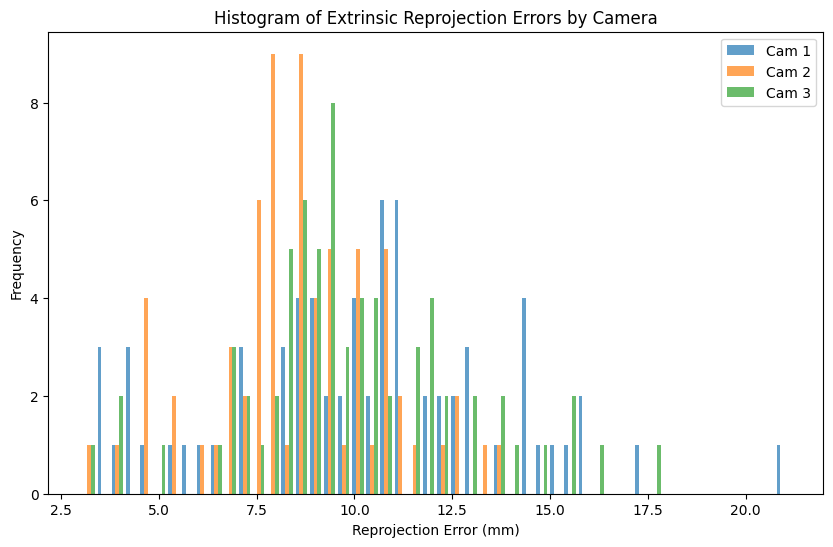

In [ ]:
#| code-fold: true

plt.figure(figsize=(10, 6))
plt.hist([df['cam1_mm'], df['cam2_mm'], df['cam3_mm']], bins=50, label=['Cam 1', 'Cam 2', 'Cam 3'], alpha=0.7)
plt.xlabel('Reprojection Error (mm)')
plt.ylabel('Frequency')
plt.title('Histogram of Extrinsic Reprojection Errors by Camera')
plt.legend()
plt.show()

The only session that is relatively high (above 20 mm) is session 19. Given that it does not exceed the acceptable threshold of 25 mm and the triangulation also does not exceed this threshold (see below), we will keep this session for further analysis.

## Triangulation error

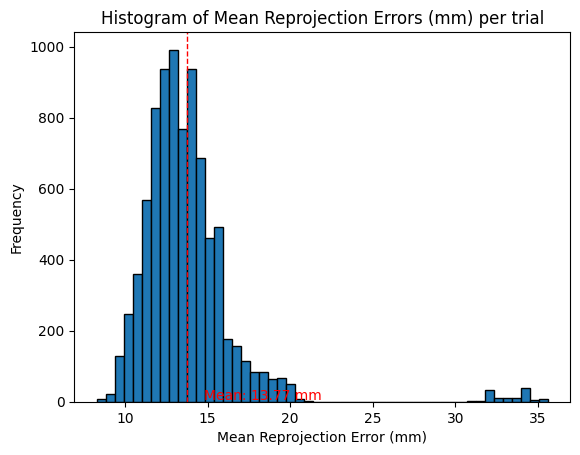

In [ ]:
#| code-fold: true

%matplotlib inline
import matplotlib.pyplot as plt

plt.hist(df['mean_reprojection_error_mm'].dropna(), bins=50, edgecolor='black')
plt.title('Histogram of Mean Reprojection Errors (mm) per trial')
plt.xlabel('Mean Reprojection Error (mm)')
plt.ylabel('Frequency')
plt.axvline(mean_repro, color='red', linestyle='dashed', linewidth=1)
plt.text(mean_repro + 1, 5, f'Mean: {mean_repro:.2f} mm', color='red')
plt.show()



In [ ]:
# create a mean reprojection error per session

df['session'] = df['trial_name'].apply(lambda x: '_'.join(x.split('_')[:2]))
session_means = df.groupby('session')['mean_reprojection_error_mm'].mean().reset_index()
session_means['mean_reprojection_error_mm'] = session_means['mean_reprojection_error_mm'].round(3)
session_means.head(150)

,session,mean_reprojection_error_mm
0,10_1,13.484
1,10_2,13.467
2,11_1,11.407
3,11_2,11.032
4,12_1,10.936
...,...,...
127,7_2,33.558
128,8_1,11.188
129,8_2,11.340
130,9_1,11.393


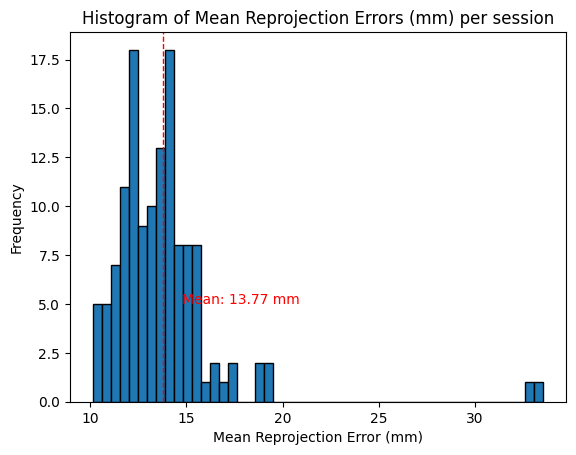

In [ ]:
#| code-fold: true

%matplotlib inline
import matplotlib.pyplot as plt

plt.hist(session_means['mean_reprojection_error_mm'].dropna(), bins=50, edgecolor='black')
plt.title('Histogram of Mean Reprojection Errors (mm) per session')
plt.xlabel('Mean Reprojection Error (mm)')
plt.ylabel('Frequency')
plt.axvline(mean_repro, color='red', linestyle='dashed', linewidth=1)
plt.text(mean_repro + 1, 5, f'Mean: {mean_repro:.2f} mm', color='red')
plt.show()


# Inspecting through animation

In [ ]:
def trc_to_csv(file, framerate=60):
    """
    Convert TRC motion capture data to a CSV format DataFrame.

    Args:
        file (str): Path to the TRC file to be converted.
        framerate (int, optional): Framerate of the motion capture data. Defaults to 60.

    Returns:
        pd.DataFrame: A DataFrame containing the motion capture data with separated x, y, z columns for each marker and a time column.
    """
    
    mocap_data = TRCData()
    mocap_data.load(os.path.abspath(file))
    num_frames = mocap_data['NumFrames']
    markernames = mocap_data['Markers'] # the marker names are not

    # Convert mocap_data to pandas dataframe
    mocap_data_df = pd.DataFrame(mocap_data, columns=mocap_data['Markers'])
    # Each value within the dataframe consists a list of x,y,z coordinates, we want to seperate these out so that each marker and dimension has its own column
    colnames = []
    for marker in markernames:
        colnames.append(marker + '_x')
        colnames.append(marker + '_y')
        colnames.append(marker + '_z')

    # Create a new DataFrame to store separated values
    new_df = pd.DataFrame()

    # Iterate through each column in the original DataFrame
    for column in mocap_data_df.columns:
        # Extract the x, y, z values from each cell
        xyz = mocap_data_df[column].tolist()
        # Create a new DataFrame with the values in the cell separated into their own columns
        xyz_df = pd.DataFrame(xyz, columns=[column + '_x', column + '_y', column + '_z'])
        # Add the new columns to the new DataFrame
        new_df = pd.concat([new_df, xyz_df], axis=1)

    # Add a new time column to the new dataframe assuming the framerate was 60 fps
    time = []
    ts = 0
    for i in range(0, int(num_frames)):
        ts = ts + 1/framerate
        time.append(ts)

    # Add the time column to the new dataframe
    new_df['Time'] = time

    return new_df


In [ ]:
#| echo: false

# import pandas as pd
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import Video

# This is where we story 3D coordinates
trackingfolders = glob.glob(os.path.join(curfolder, 'projectdata', '*', '*', 'pose-3d'), recursive=True)

# This is where we store raw data
rawfolders = glob.glob(os.path.join(curfolder, 'projectdata', '*', '*', 'raw-2d'), recursive=True)

# Pick one and get the csv files
trctracked = glob.glob(os.path.join(trackingfolders[25], '*.trc'))
fileexample = trctracked[1]

# Get the same video
videoexample = glob.glob(os.path.join(rawfolders[25], '*.avi'))

# Convert to csv
MT_tracking = trc_to_csv(fileexample, framerate=60)

# Create a figure and axis
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Define the number of frames
num_frames = len(MT_tracking)

# Define the scatter plot
scatter = ax.scatter([], [], [], marker='o')

# Update function for animation
def update(frame):
    ax.clear()
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_title('3D Animation')
    
    # Set the limits of the axes based on the maximum values
    ax.set_xlim3d(-3, 1)
    ax.set_ylim3d(1, 3)
    ax.set_zlim3d(-2.5, 0)

    # Plot the data for the current frame
    frame_data = MT_tracking.iloc[frame]
    x = frame_data.filter(like='_x')
    y = frame_data.filter(like='_y')
    z = frame_data.filter(like='_z')
    scatter = ax.scatter(x, y, z*-1, marker='o') # Notice that we need to invert Z-dimension
    return scatter,

# Create the animation
ani = FuncAnimation(fig, update, frames=num_frames, interval=1000/60)

# Close the figure to prevent displaying the first frame
plt.close(fig)

# Save the animation as a video
ani.save('3D_animation.mp4', writer='ffmpeg')

# Display the animation
video_path = '3D_animation.mp4'
Video(video_path, embed=True, width=600)

Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1000x600 -pix_fmt rgba -framerate 59.99999999999999 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y 3D_animation.mp4


This is the video that it corresponds to

In [51]:
#| echo: false

import tempfile
import subprocess

# Create a temporary folder
temp_dir = tempfile.mkdtemp()

# Get the same video
videoexample = glob.glob(os.path.join(rawfolders[528], '*.avi'))
print(videoexample)
# what is the duration of the video in ms
cap = cv2.VideoCapture(videoexample[1])
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration_ms = (frame_count / fps) * 1000
print('Duration of the video in ms: ' + str(duration_ms))
# Define input and output paths
sample = videoexample[1]
mp4_path = os.path.join(temp_dir, "converted_rawtrackingvideo.mp4")  # Save MP4 in temp folder


# Convert AVI to MP4 with video and audio
if not os.path.exists(mp4_path):
    subprocess.run([
        "ffmpeg", "-i", sample, 
        "-vcodec", "libx264", "-acodec", "aac", "-b:a", "192k",  # Ensure audio is included
        "-crf", "23", "-preset", "fast", mp4_path
    ])

# Display the video inside Jupyter Notebook
Video(mp4_path, embed=True, width=400)

['f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_14_1\\14_1_17_p1\\raw-2d\\14_1_trial_17_p1_kotsen_combinatie_video_raw_cam1.avi', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_14_1\\14_1_17_p1\\raw-2d\\14_1_trial_17_p1_kotsen_combinatie_video_raw_cam2.avi', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_14_1\\14_1_17_p1\\raw-2d\\14_1_trial_17_p1_kotsen_combinatie_video_raw_cam3.avi']
Duration of the video in ms: 2785.714285714286


We can see that there are some issues with the tracking that we need to correct for:

- the orientation of the Z-axis is inverted - this is probably an artifact of calibration where we ticked corners from top to bottom. Because this is important for working with forces (as gravity needs to be correctly oriented), we will invert the Z-axis immediately in this script. We use code that is adapted from [here](https://github.com/perfanalytics/pose2sim/blob/main/Pose2Sim/Utilities/trc_rotate.py)
- as we see in the animation, Y and Z axis are flipped. Again, for correct estimation of forces, we need to correct for this.
- lastly, we can see that the skeleton does not align with the ground plane, i.e., the feet are not on the ground (Z=0). We will therefore also correct for this by shifting the whole skeleton up or down such that the lowest point (foot) is at Z=0. This is done using part of Pose2sim [augmentation script](https://github.com/perfanalytics/pose2sim/blob/9500db70af064f115d734426f575b0c5eb554c5b/Pose2Sim/markerAugmentation.py#L313)
- we will further smooth the data using Savitzky-Golay filter to remove high-frequency noise and prevent its propagation into inverse kinematics and dynamics.

# TODO: REPLOT

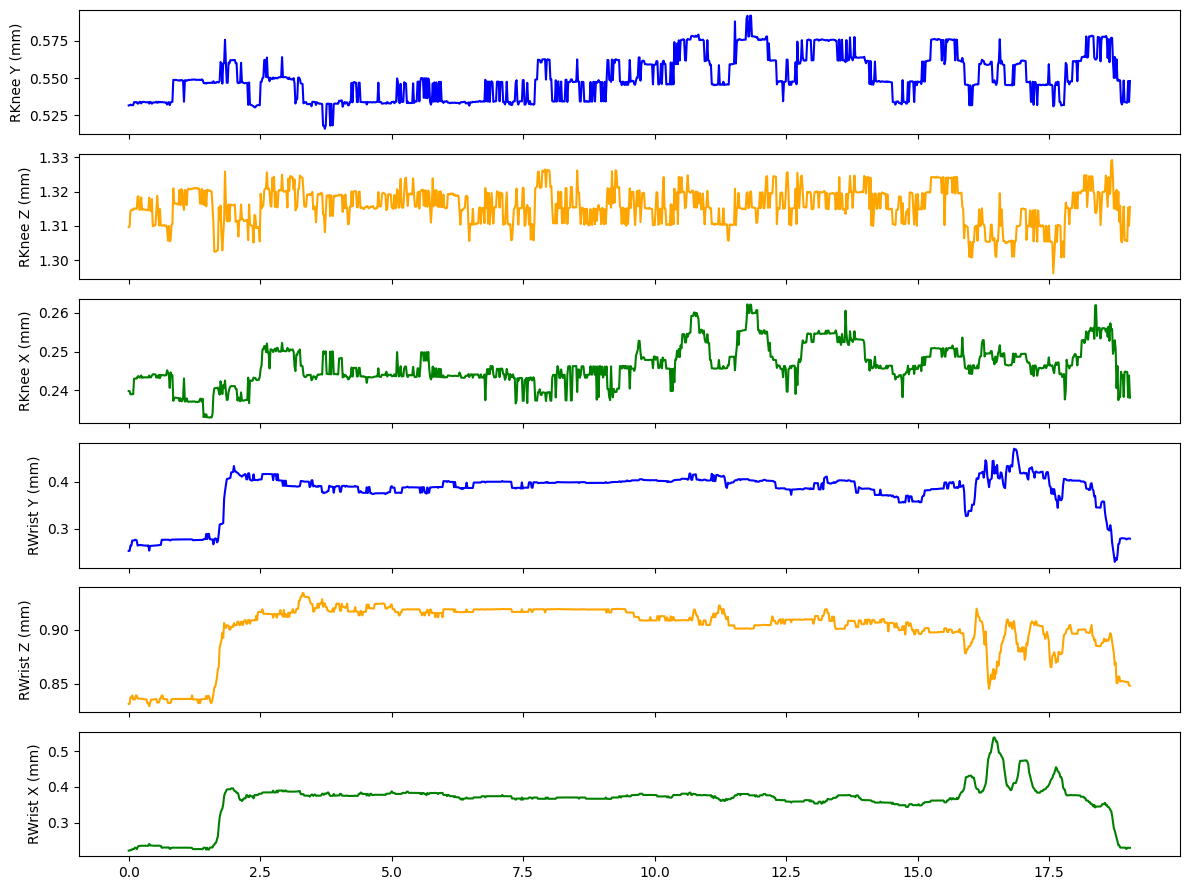

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

trctracked = glob.glob(os.path.join(trackingfolders[1000], '*.trc'))
fileexample = trctracked[0]
trc_path = fileexample

with open(trc_path, "r") as f:
    # skip first 3 header lines
    for _ in range(3):
        f.readline()
    marker_header = f.readline().rstrip("\n")

parts = marker_header.split("\t")

# Build dict: marker_name → marker_index (1-based)
marker_indices = {}
marker_num = 0
for name in parts[2:]:  # skip "Frame#" / "Time"
    if name != "":
        marker_num += 1
        marker_indices[name] = marker_num

rknee_idx  = marker_indices["RKnee"]
rwrist_idx = marker_indices["RWrist"]

# Read trc file
df = pd.read_csv(trc_path, sep="\t", skiprows=4, encoding="utf-8")

frames = df.iloc[:, 0]
time   = df.iloc[:, 1]
coords = df.drop(df.columns[[0, 1]], axis=1)

# Marker coordinate indexing helper
def xyz_columns(marker_index):
    """
    Given a marker index n (1-based),
    return the *column labels* ("Xn","Yn","Zn") that appear in coords.
    """
    base = 3 * (marker_index - 1)
    return coords.columns[base], coords.columns[base+1], coords.columns[base+2]

rknee_x_col, rknee_y_col, rknee_z_col   = xyz_columns(rknee_idx)
rwrist_x_col, rwrist_y_col, rwrist_z_col = xyz_columns(rwrist_idx)

# Extract traces
rknee_x = coords[rknee_x_col]
rknee_y = coords[rknee_y_col]
rknee_z = coords[rknee_z_col]

rwrist_x = coords[rwrist_x_col]
rwrist_y = coords[rwrist_y_col]
rwrist_z = coords[rwrist_z_col]

# Plot
fig, axes = plt.subplots(6, 1, sharex=True, figsize=(12, 9))

# RKnee, y
axes[0].plot(time, rknee_y, label="RKnee Y", color="blue")
axes[0].set_ylabel("RKnee Y (mm)")

# RKnee, z
axes[1].plot(time, rknee_z, label="RKnee Z", color="orange")
axes[1].set_ylabel("RKnee Z (mm)")

# RKnee, x
axes[2].plot(time, rknee_x, label="RKnee X", color="green")
axes[2].set_ylabel("RKnee X (mm)")

# RWrist, y
axes[3].plot(time, rwrist_y, label="RWrist Y", color="blue")
axes[3].set_ylabel("RWrist Y (mm)")

# RWrist, z
axes[4].plot(time, rwrist_z, label="RWrist Z", color="orange")
axes[4].set_ylabel("RWrist Z (mm)")

# RWrist, x
axes[5].plot(time, rwrist_x, label="RWrist X", color="green")
axes[5].set_ylabel("RWrist X (mm)")


plt.tight_layout()
plt.show()

Comparing it to the video above, we can see that the tracking is a bit jittery. Since this noise is likely going to propagate when solving inverse kinematics using OpenSim, we will apply Savitzky-Golay filter to smooth the coordinates further.

# Inversion, offset, smoothing plus csv-convert on all files

In [ ]:
import os
import pandas as pd
import scipy.signal

upperbodycols = [
    'Head', 'Neck', 'RShoulder', 'RElbow', 'RWrist',
    'LShoulder', 'LElbow', 'LWrist', 'Nose',
    'RIndex', 'LIndex'
]

lowerbodycols = [
    'RHip', 'RKnee', 'RAnkle', 'RHeel',
    'LHip', 'LKnee', 'LAnkle', 'LHeel'
]

def remove_global_pitch_safe(coords_out, marker_indices, max_correction_deg=30):
    """
    Corrects global pitch based on pelvis orientation only.
    Limits correction to +/- max_correction_deg to avoid flips.
    Applies correction ONLY based on the first frame.

    Args:
        coords_out (pd.DataFrame): DataFrame containing marker coordinates (columns: X1,Y1,Z1,...)
        marker_indices (dict): Mapping of marker names to their 1-based indices
        max_correction_deg (float): Maximum allowed correction in degrees (default: 30)
    """

    pelvis_markers = ['LHip', 'RHip']
    for pm in pelvis_markers:
        if pm not in marker_indices:
            print("[WARN] Missing pelvis markers; skipping pitch correction")
            return coords_out

    def get_first_frame(marker):
        idx = marker_indices[marker]
        base = 3 * (idx - 1)
        return coords_out.iloc[0, base:base+3].values

    # Pelvis center
    L = get_first_frame('LHip')
    R = get_first_frame('RHip')
    pelvis = (L + R) / 2

    # Estimate pitch using pelvis-to-shoulder vector IF shoulders exist
    if all(m in marker_indices for m in ['LShoulder', 'RShoulder']):
        LS = get_first_frame('LShoulder')
        RS = get_first_frame('RShoulder')
        shoulders = (LS + RS) / 2
        vec = shoulders - pelvis
    else:
        # fallback: use hip-to-knee
        LK = get_first_frame('LKnee')
        RK = get_first_frame('RKnee')
        vec = ((LK + RK) / 2) - pelvis

    dy = vec[1]
    dz = vec[2]

    raw_pitch = np.degrees(np.arctan2(dz, dy))

    # Clamp correction
    correction = np.clip(raw_pitch, -max_correction_deg, max_correction_deg)

    rad = np.radians(-correction)

    cos_t = np.cos(rad)
    sin_t = np.sin(rad)

    # Rotate all frames around X-axis
    for marker, idx in marker_indices.items():
        base = 3 * (idx - 1)

        Y = coords_out.iloc[:, base + 1].values
        Z = coords_out.iloc[:, base + 2].values

        Y_new = cos_t * Y - sin_t * Z
        Z_new = sin_t * Y + cos_t * Z

        coords_out.iloc[:, base + 1] = Y_new
        coords_out.iloc[:, base + 2] = Z_new

    print(f"[OK] Applied pitch correction of {correction:.2f} degrees")
    return coords_out

def remove_global_roll_safe(coords_out, marker_indices, max_correction_deg=15):
    """
    Corrects global roll (left/right tilt) using pelvis markers (LHip, RHip).
    Applies rotation around Z-axis.
    Limits correction to +/- max_correction_deg.

    Args:
            coords_out (pd.DataFrame): DataFrame containing marker coordinates (columns: X1,Y1,Z1,...)
            marker_indices (dict): Mapping of marker names to their 1-based indices
            max_correction_deg (float): Maximum allowed correction in degrees (default: 15)

    """

    if not all(m in marker_indices for m in ['LHip', 'RHip']):
        print("[WARN] Missing pelvis markers; skipping roll correction")
        return coords_out

    def ff(marker):
        idx = marker_indices[marker]
        base = 3 * (idx - 1)
        return coords_out.iloc[0, base:base+3].values

    L = ff('LHip')
    R = ff('RHip')

    # Vertical difference between hips
    dy = L[1] - R[1]
    dx = L[0] - R[0]

    # Roll angle (hip height difference)
    raw_roll = np.degrees(np.arctan2(dy, dx))

    # Clamp
    correction = np.clip(raw_roll, -max_correction_deg, max_correction_deg)

    rad = np.radians(+correction)
    cos_t = np.cos(rad)
    sin_t = np.sin(rad)

    # Rotate all points around Z axis
    for marker, idx in marker_indices.items():
        base = 3 * (idx - 1)

        X = coords_out.iloc[:, base + 0].values
        Y = coords_out.iloc[:, base + 1].values

        X_new = cos_t * X - sin_t * Y
        Y_new = sin_t * X + cos_t * Y

        coords_out.iloc[:, base + 0] = X_new
        coords_out.iloc[:, base + 1] = Y_new

    print(f"[OK] Applied roll correction of {correction:.2f} degrees")
    return coords_out

def process_trc(trc_path):
    """
    Pipeline for a single TRC:

      1. load TRC
      2. apply axis transform per marker:
           X_new = X_old
           Y_new = -Z_old
           Z_new =  Y_old
      3. smooth (upper body: 11/3, lower body: 25/3, with fallbacks)
      4. shift vertically so feet are on the floor (min Y of feet ≈ 0)
      5. save ONE final TRC: <name>_processed.trc
      6. save ONE CSV with columns Marker_x, Marker_y, Marker_z, ..., Time

    Returns:
        final_trc_path, final_csv_path
    """

    base, ext = os.path.splitext(trc_path)
    final_trc_path = base + "_processed.trc"
    final_csv_path = base + "_processed.csv"

    # Read header and marker names
    with open(trc_path, "r") as f:
        header = [next(f) for _ in range(5)]

    marker_header = header[3].rstrip("\n")
    parts = marker_header.split("\t")

    # marker_name -> index (1-based, matching X1/Y1/Z1,...)
    marker_indices = {}
    marker_num = 0
    for name in parts[2:]:   # skip "Frame#" and "Time"
        if name != "":
            marker_num += 1
            marker_indices[name] = marker_num

    # Read numeric block
    df = pd.read_csv(trc_path, sep="\t", skiprows=4, encoding="utf-8")

    # df columns: ['Frame#','Time','X1','Y1','Z1',..., 'Xn','Yn','Zn']
    frames = df.iloc[:, 0]
    time_col = df.iloc[:, 1]
    coords = df.drop(df.columns[[0, 1]], axis=1)

    # this will hold transformed (invertZ + swap Y/Z) and smoothed coords
    coords_out = coords.copy()

    # Axis transform
    for marker_name, marker_idx in marker_indices.items():
        base_idx = 3 * (marker_idx - 1)
        x_col = coords.columns[base_idx]
        y_col = coords.columns[base_idx + 1]
        z_col = coords.columns[base_idx + 2]

        X_old = coords[x_col]
        Y_old = coords[y_col]
        Z_old = coords[z_col]

        coords_out[x_col] = X_old           # X_new
        coords_out[y_col] = -Z_old          # Y_new = -Z_old (invert original Z)
        coords_out[z_col] = Y_old           # Z_new =  Y_old

    # Smooth
    for marker_name, marker_idx in marker_indices.items():

        # choose smoothing parameters
        if marker_name in upperbodycols:
            primary = (11, 3)
        elif marker_name in lowerbodycols:
            primary = (25, 3)
        else:
            primary = (11, 3)

        fallbacks = [(10, 2), (5, 2)]

        base_idx = 3 * (marker_idx - 1)
        col_names = [
            coords_out.columns[base_idx],
            coords_out.columns[base_idx + 1],
            coords_out.columns[base_idx + 2],
        ]

        for col_name in col_names:
            signal = coords_out[col_name].values
            applied = False

            for win, ord_ in (primary,) + tuple(fallbacks):
                try:
                    coords_out[col_name] = scipy.signal.savgol_filter(
                        signal, win, ord_
                    )
                    applied = True
                    break
                except ValueError:
                    continue

            if not applied:
                coords_out[col_name] = signal

    # Feet on floor
    ground_markers = ['RHeel', 'LHeel', 'RAnkle', 'LAnkle']

    ground_y_cols = []
    for m in ground_markers:
        if m in marker_indices:
            idx = marker_indices[m]
            base_idx = 3 * (idx - 1)
            y_col = coords_out.columns[base_idx + 1]
            ground_y_cols.append(y_col)

    if ground_y_cols:
        min_y = coords_out[ground_y_cols].min().min()

        for marker_name, marker_idx in marker_indices.items():
            base_idx = 3 * (marker_idx - 1)
            y_col = coords_out.columns[base_idx + 1]
            coords_out[y_col] = coords_out[y_col] - min_y

    if 'Session_52_' in trc_path:
        print("[INFO] Applying special global roll correction for trial starting with '52_'")
        coords_out = remove_global_roll_safe(coords_out, marker_indices)

    coords_out = remove_global_pitch_safe(coords_out, marker_indices)

    # Save final TRC
    with open(final_trc_path, "w") as out:
        for line in header:
            out.write(line)

        df_out = coords_out.copy()
        df_out.insert(0, "Time", time_col)
        df_out.insert(0, "Frame#", frames)

        df_out.to_csv(out, sep="\t", index=False, header=None, lineterminator="\n")

    print(f"[OK] Final TRC saved → {final_trc_path}")

    # Save CSV using real timestamps from TRC (not synthetic)
    new_df = pd.DataFrame()

    for marker_name, marker_idx in marker_indices.items():
        base_idx = 3 * (marker_idx - 1)
        x_col = coords_out.columns[base_idx]
        y_col = coords_out.columns[base_idx + 1]
        z_col = coords_out.columns[base_idx + 2]

        new_df[f"{marker_name}_x"] = coords_out[x_col].values
        new_df[f"{marker_name}_y"] = coords_out[y_col].values
        new_df[f"{marker_name}_z"] = coords_out[z_col].values

    new_df["Time"] = time_col.values  # real timestamps from TRC

    new_df.to_csv(final_csv_path, index=False)
    print(f"[OK] Final CSV saved → {final_csv_path}")

    return final_trc_path, final_csv_path


In [ ]:
#| eval: false

trctoconvert = []

for j in pcnfolders:
    # Here we store the 3D pose data
    posefolder = 'pose-3d'
    trcfiles = glob.glob(os.path.join(j, posefolder, '*.trc'))
    
    # keep only butterworth smoothed files
    trcfiles = [file for file in trcfiles if 'butterworth' in file]
    trcfiles = [file for file in trcfiles if 'processed.trc' not in file] # get rid of the processed ones already
    
    trctoconvert = trctoconvert + trcfiles

# Loop through files and convert to csv
for file in trctoconvert:
    print(file)
    
    # Process each TRC through the full pipeline
    final_trc, final_csv = process_trc(file)

Check the animation again

In [ ]:
#| echo: false

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import Video
import pandas as pd

# find in pcnfolders a _processed.trc file
processed_files = []
for j in pcnfolders:
    posefolder = 'pose-3d'
    trcfiles = glob.glob(os.path.join(j, posefolder, '*_processed.trc'))
    
    # if trc files empty, flag it
    if len(trcfiles) == 0:
        print(f'processed trc file missing in {j}')
         
    processed_files = processed_files + trcfiles

print('Total processed TRC files:', len(processed_files))

# Load in the processed trc
sample = processed_files[50]
MT_tracking = pd.read_csv(sample, sep="\t", header=4, encoding="utf-8")

# Create a figure and axis
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Define the number of frames
num_frames = len(MT_tracking)

# Define the scatter plot
scatter = ax.scatter([], [], [], marker='o')

# Create the animation
ani = FuncAnimation(fig, update, frames=num_frames, interval=1000/60)

# Close the figure to prevent displaying the first frame
plt.close(fig)

# Save the animation as a video
ani.save('3D_animation_processed.mp4', writer='ffmpeg')

# Display the animation
video_path = '3D_animation_processed.mp4'
Video(video_path, embed=True, width=600)



Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1000x600 -pix_fmt rgba -framerate 59.99999999999999 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y 3D_animation_processed.mp4


# TODO. RERUN


f:\flesh_data_processed\02_MotionTracking_processing\projectdata\Session_18_2\18_2_18_p0\pose-3d\18_2_18_p0_0-532_filt_butterworth_processed.trc
Last value of RKnee Y:  0.4251813105597127
Last value of RKnee Z:  0.4995449304526668
Last value of RKnee X:  0.2258259798667819
Last value of RWrist Y:  1.2269738680967377
Last value of RWrist Z:  0.0617365211121083
Last value of RWrist X:  0.1605925424336976
Last time value:  9.0


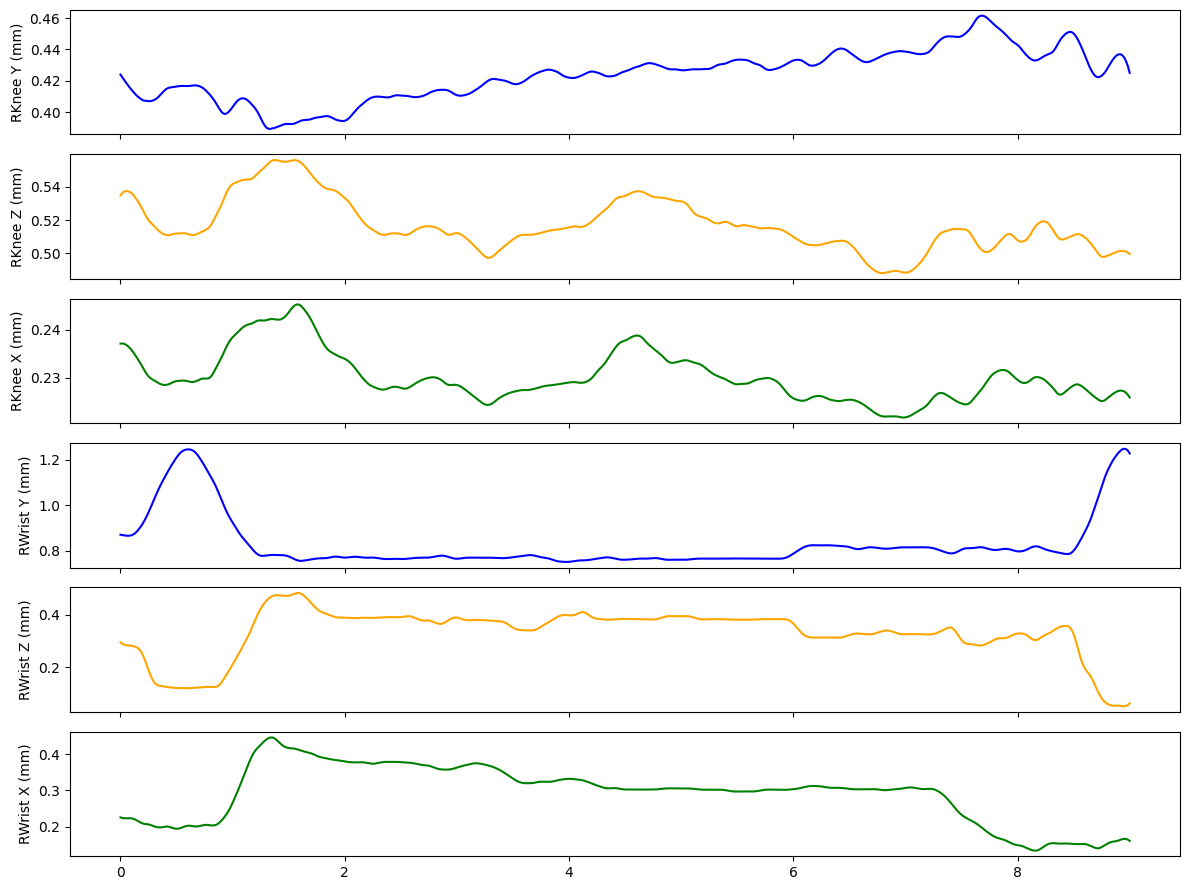

In [ ]:
# plot as before

# load in the inverted trc
sample = processed_files[1094]
print(sample)
MT_tracking = pd.read_csv(sample, sep="\t", header=4, encoding="utf-8")


with open(sample, "r") as f:
    # skip first 3 header lines
    for _ in range(3):
        f.readline()
    marker_header = f.readline().rstrip("\n")

parts = marker_header.split("\t")

# Build dict: marker_name → marker_index (1-based)
marker_indices = {}
marker_num = 0
for name in parts[2:]:  # skip "Frame#" / "Time"
    if name != "":
        marker_num += 1
        marker_indices[name] = marker_num

rknee_idx  = marker_indices["RKnee"]
rwrist_idx = marker_indices["RWrist"]

# Read trc file
df = pd.read_csv(sample, sep="\t", skiprows=4, encoding="utf-8")

frames = df.iloc[:, 0]
time   = df.iloc[:, 1]
coords = df.drop(df.columns[[0, 1]], axis=1)

# Marker coordinate indexing helper
def xyz_columns(marker_index):
    """
    Given a marker index n (1-based),
    return the *column labels* ("Xn","Yn","Zn") that appear in coords.
    """
    base = 3 * (marker_index - 1)
    return coords.columns[base], coords.columns[base+1], coords.columns[base+2]

rknee_x_col, rknee_y_col, rknee_z_col   = xyz_columns(rknee_idx)
rwrist_x_col, rwrist_y_col, rwrist_z_col = xyz_columns(rwrist_idx)

# Extract traces
rknee_x = coords[rknee_x_col]
rknee_y = coords[rknee_y_col]
rknee_z = coords[rknee_z_col]

rwrist_x = coords[rwrist_x_col]
rwrist_y = coords[rwrist_y_col]
rwrist_z = coords[rwrist_z_col]

# Plot
fig, axes = plt.subplots(6, 1, sharex=True, figsize=(12, 9))

# RKnee, y
axes[0].plot(time, rknee_y, label="RKnee Y", color="blue")
axes[0].set_ylabel("RKnee Y (mm)")

# RKnee, z
axes[1].plot(time, rknee_z, label="RKnee Z", color="orange")
axes[1].set_ylabel("RKnee Z (mm)")

# RKnee, x
axes[2].plot(time, rknee_x, label="RKnee X", color="green")
axes[2].set_ylabel("RKnee X (mm)")

# RWrist, y
axes[3].plot(time, rwrist_y, label="RWrist Y", color="blue")
axes[3].set_ylabel("RWrist Y (mm)")

# RWrist, z
axes[4].plot(time, rwrist_z, label="RWrist Z", color="orange")
axes[4].set_ylabel("RWrist Z (mm)")

# RWrist, x
axes[5].plot(time, rwrist_x, label="RWrist X", color="green")
axes[5].set_ylabel("RWrist X (mm)")

plt.tight_layout()
plt.show()

# Inverse kinematics with Pose2sim

Currently, Pose2sim implements two steps of the OpenSim pipeline - scaling and inverse kinematics.

In scaling, we scale the model to match the anthropometry of the subject. We use the Pose2sim model with 135 keypoints (BODY_135). While OpenSim requires t-pose for scaling the participants, Pose2Sim uses every trial's coordinates to estimate the participant's anthropometry. We end up with a model scaled for each participant.

In inverse kinematics, we use the scaled model to estimate the joint angles of the participant. We use the motion tracking data to estimate the joint angles. Joint angles are saved as .mot files.

In [ ]:
#| eval: false

# Prepare special log txt
error_log = os.path.join(curfolder, 'pose2sim_error_IK_log.txt')
if not os.path.exists(error_log):
    with open(error_log, 'w') as f:
        f.write('Pose2Sim processing error log\n')
        f.write('============================\n\n')

for i in folderstotrack:
    os.chdir(i)
    print('working on folder: ' + i)

    sessionID = i.split(os.sep)[-1].split('_')[1]

    try:
        print('Step: inverse kinematics')
        Pose2Sim.kinematics()

    except:
        print('IK failed')
        log_step_error('Kinematics', sessionID, i, error_log)
        continue

First, check that every folder has kinematics with osim and mot files

In [ ]:
# Get all the folders per session, per participant
pcnfolders = []

for i in folderstotrack:
    pcnfolders_in_session = glob.glob(os.path.join(i, '*'))   
    pcnfolders = pcnfolders + pcnfolders_in_session 

# Get rid of all pontetially confusing files/folders
pcnfolders = [x for x in pcnfolders if 'Config' not in x]
pcnfolders = [x for x in pcnfolders if 'opensim' not in x]
pcnfolders = [x for x in pcnfolders if 'xml' not in x]
pcnfolders = [x for x in pcnfolders if 'ResultsInverseDynamics' not in x]
pcnfolders = [x for x in pcnfolders if 'ResultsInverseKinematics' not in x]
pcnfolders = [x for x in pcnfolders if 'sto' not in x]
pcnfolders = [x for x in pcnfolders if 'txt' not in x]
pcnfolders = [x for x in pcnfolders if 'calibration' not in x]
print(pcnfolders[0:10])


print('Length of pcnfolders: ' + str(len(pcnfolders)))

for j in pcnfolders:
    ikfolder = os.path.join(j, 'kinematics')
    osimfiles = glob.glob(os.path.join(ikfolder, '*.osim'))
    if len(osimfiles) == 0:
        print('Warning: No osim files found in ' + ikfolder)
    motfiles = glob.glob(os.path.join(ikfolder, '*.mot'))
    if len(motfiles) == 0:
        print('Warning: No mot files found in ' + ikfolder)

# TODO: delete animation in 9_2

## TODO RERUN IK error inspection

Then, for each file get marker_error_RMS and max_error from the errors.sto files

In [ ]:
ikerrors = []

for j in pcnfolders:
    ikfolder = os.path.join(j, 'kinematics')
    errorfiles = glob.glob(os.path.join(ikfolder, '*_ik_marker_errors.sto'))
    if len(errorfiles) == 0:
        print('Warning: No ik error files found in ' + ikfolder)

    error = pd.read_csv(errorfiles[0], sep="\t", skiprows=6)
    # get mean and sd of marker_error_RMS
    mean_error = error['marker_error_RMS'].mean()
    sd_error = error['marker_error_RMS'].std()

    # get mean and sd of marker_error_max
    max_error = error['marker_error_max'].mean()
    sd_max_error = error['marker_error_max'].std()

    filename = os.path.basename(j)

    ikerrors.append({
        'pcnfolder': filename,
        'mean_marker_error_RMS': mean_error,
        'sd_marker_error_RMS': sd_error,
        'mean_marker_error_max': max_error,
        'sd_marker_error_max': sd_max_error
    })

# create dataframe
df_ikerrors = pd.DataFrame(ikerrors)

# round all to three decimal places
df_ikerrors = df_ikerrors.round(3)
df_ikerrors.head(15)
    

,pcnfolder,mean_marker_error_RMS,sd_marker_error_RMS,mean_marker_error_max,sd_marker_error_max
0,10_1_11_p1,0.036,0.003,0.078,0.014
1,10_1_12_p1,0.041,0.011,0.102,0.049
2,10_1_13_p1,0.032,0.004,0.060,0.021
3,10_1_14_p1,0.036,0.005,0.075,0.009
4,10_1_15_p1,0.047,0.022,0.102,0.062
5,10_1_16_p1,0.029,0.002,0.056,0.007
6,10_1_17_p1,0.032,0.003,0.065,0.008
7,10_1_20_p0,0.087,0.028,0.218,0.067
8,10_1_21_p0,0.035,0.004,0.069,0.012
9,10_1_22_p0,0.041,0.009,0.092,0.031


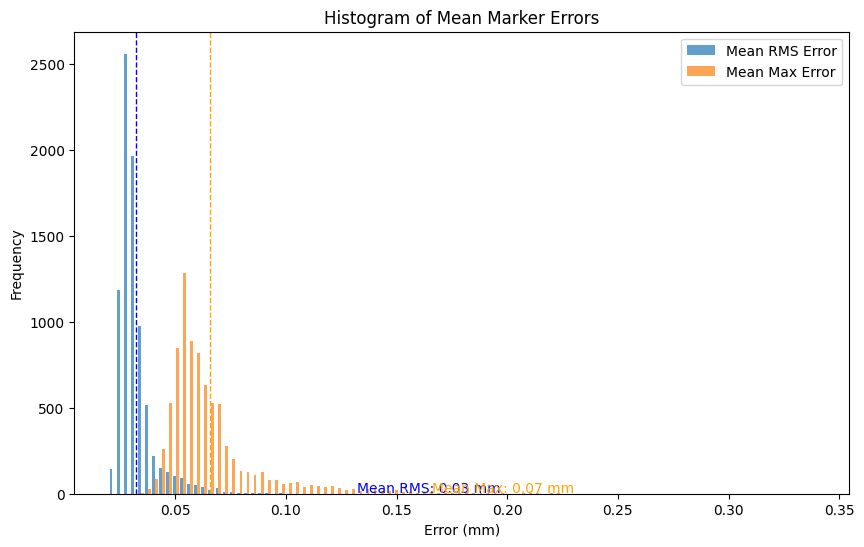

In [ ]:
#| code-fold: true

plt.figure(figsize=(10, 6))
plt.hist([df_ikerrors['mean_marker_error_RMS'], df_ikerrors['mean_marker_error_max']], bins=100, label=['Mean RMS Error', 'Mean Max Error'], alpha=0.7)
# make a vertical line at mean of mean_marker_error_RMS
mean_rms = df_ikerrors['mean_marker_error_RMS'].mean()
plt.axvline(mean_rms, color='blue', linestyle='dashed', linewidth=1)
plt.text(mean_rms + 0.1, 5, f'Mean RMS: {mean_rms:.2f} mm', color='blue')
# make a vertical line at mean of mean_marker_error_max
mean_max = df_ikerrors['mean_marker_error_max'].mean()
plt.axvline(mean_max, color='orange', linestyle='dashed', linewidth=1)
plt.text(mean_max + 0.1, 5, f'Mean Max: {mean_max:.2f} mm', color='orange')
plt.xlabel('Error (mm)')
plt.ylabel('Frequency')
plt.title('Histogram of Mean Marker Errors')
plt.legend()
plt.show()

RMS error between 0.02–0.04 m is considered acceptable

In [13]:
# create column session, and populate it with first two elements from pcnfolder
df_ikerrors['session'] = df_ikerrors['pcnfolder'].apply(lambda x: '_'.join(x.split('_')[:2]))

# create mean+sd per session
session_ikerrors = df_ikerrors.groupby('session').agg({
    'mean_marker_error_RMS': 'mean',
    'sd_marker_error_RMS': 'mean',
    'mean_marker_error_max': 'mean',
    'sd_marker_error_max': 'mean'
}).reset_index()

# round all to three decimal places
session_ikerrors = session_ikerrors.round(3)

session_ikerrors.head(15)

,session,mean_marker_error_RMS,sd_marker_error_RMS,mean_marker_error_max,sd_marker_error_max
0,10_1,0.036,0.006,0.075,0.019
1,10_2,0.037,0.008,0.077,0.027
2,11_1,0.030,0.005,0.059,0.014
3,11_2,0.030,0.005,0.059,0.016
4,12_1,0.028,0.003,0.057,0.012
5,12_2,0.030,0.006,0.061,0.018
6,13_1,0.034,0.007,0.070,0.022
7,13_2,0.032,0.007,0.066,0.022
8,14_1,0.029,0.004,0.059,0.015
9,14_2,0.029,0.003,0.059,0.012


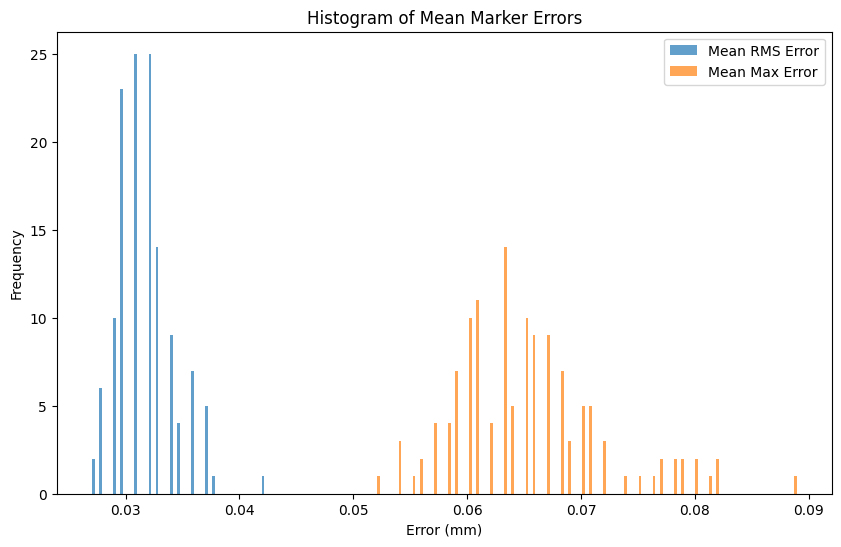

In [ ]:
#| code-fold: true

plt.figure(figsize=(10, 6))
plt.hist([session_ikerrors['mean_marker_error_RMS'], session_ikerrors['mean_marker_error_max']], bins=100, label=['Mean RMS Error', 'Mean Max Error'], alpha=0.7)
plt.xlabel('Error (mm)')
plt.ylabel('Frequency')
plt.title('Histogram of Mean Marker Errors')
plt.legend()
plt.show()

For the higher errors, check in logs.txt what is the marker with max error (if it's not concerning upper limbs - besides fingers - we can ignore it for now)

In [ ]:
import re
import os
import glob
from collections import Counter
from pathlib import Path
import csv

log_extension = ".log"  # not strictly needed anymore, kept for clarity
output_csv = "most_common_marker_per_log.csv"

# Marker that always indicates the start of a new run
RUN_START = "[info] Updating Model file from 40000 to latest format..."

pattern = re.compile(r"\(([^)]+)\)")

results = []

for j in pcnfolders:

    filename = os.path.basename(j)

    ikfolder = os.path.join(j, "kinematics")
    logfiles = glob.glob(os.path.join(ikfolder, "*logs.txt"))

    if len(logfiles) == 0:
        print(f"Warning: No log files found in {ikfolder}")
        continue

    log_file = Path(logfiles[0])

    with open(log_file, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    # keep only newest run
    last_run_idx = text.rfind(RUN_START)

    if last_run_idx != -1:
        text = text[last_run_idx:]
    else:
        print(f"Warning: run start marker not found in {log_file}")
        # fall back to full log

    # extract markers
    markers = pattern.findall(text)

    if not markers:
        most_common_marker = None
        count = 0
    else:
        counter = Counter(markers)
        most_common_marker, count = counter.most_common(1)[0]

    results.append({
        "log_file": filename,
        "most_common_marker": most_common_marker,
        "count": count
    })

    print(f"{filename}: {most_common_marker} ({count} times)")

# put results into dataframe
df_logs = pd.DataFrame(results)
df_logs.head(15)


10_1_11_p1: LElbow (139 times)
10_1_12_p1: RElbow (209 times)
10_1_13_p1: LElbow (71 times)
10_1_14_p1: RHeel (196 times)
10_1_15_p1: RElbow (203 times)
10_1_16_p1: RHeel (203 times)
10_1_17_p1: RHeel (163 times)
10_1_20_p0: RShoulder (647 times)
10_1_21_p0: LElbow (262 times)
10_1_22_p0: LElbow (145 times)
10_1_23_p0: RElbow (311 times)
10_1_24_p0: LHeel (231 times)
10_1_25_p0: RWrist (119 times)
10_1_26_p0: RPinky (207 times)
10_1_29_p1: RShoulder (140 times)
10_1_2_p0: RHeel (220 times)
10_1_30_p1: RElbow (85 times)
10_1_31_p1: LElbow (188 times)
10_1_32_p1: LElbow (76 times)
10_1_33_p1: RElbow (75 times)
10_1_34_p1: RKnee (114 times)
10_1_35_p1: Neck (206 times)
10_1_38_p0: RWrist (135 times)
10_1_39_p0: RPinky (317 times)
10_1_3_p0: RWrist (185 times)
10_1_40_p0: RPinky (167 times)
10_1_41_p0: RPinky (448 times)
10_1_42_p0: RWrist (126 times)
10_1_43_p0: RPinky (268 times)
10_1_44_p0: RPinky (243 times)
10_1_47_p1: RHeel (354 times)
10_1_48_p1: RHeel (371 times)
10_1_49_p1: RHeel 

,log_file,most_common_marker,count
0,10_1_11_p1,LElbow,139
1,10_1_12_p1,RElbow,209
2,10_1_13_p1,LElbow,71
3,10_1_14_p1,RHeel,196
4,10_1_15_p1,RElbow,203
5,10_1_16_p1,RHeel,203
6,10_1_17_p1,RHeel,163
7,10_1_20_p0,RShoulder,647
8,10_1_21_p0,LElbow,262
9,10_1_22_p0,LElbow,145


In [ ]:
# merge df_logs with df_ikerrors on pcnfolder/log_file
df_error_merged = pd.merge(df_ikerrors, df_logs, left_on='pcnfolder', right_on='log_file', how='left')
df_error_merged = df_error_merged.drop(columns=['log_file', 'count'])
df_error_merged.head(15)

,pcnfolder,mean_marker_error_RMS,sd_marker_error_RMS,mean_marker_error_max,sd_marker_error_max,session,most_common_marker
0,10_1_11_p1,0.036,0.003,0.078,0.014,10_1,LElbow
1,10_1_12_p1,0.041,0.011,0.102,0.049,10_1,RElbow
2,10_1_13_p1,0.032,0.004,0.060,0.021,10_1,LElbow
3,10_1_14_p1,0.036,0.005,0.075,0.009,10_1,RHeel
4,10_1_15_p1,0.047,0.022,0.102,0.062,10_1,RElbow
5,10_1_16_p1,0.029,0.002,0.056,0.007,10_1,RHeel
6,10_1_17_p1,0.032,0.003,0.065,0.008,10_1,RHeel
7,10_1_20_p0,0.087,0.028,0.218,0.067,10_1,RShoulder
8,10_1_21_p0,0.035,0.004,0.069,0.012,10_1,LElbow
9,10_1_22_p0,0.041,0.009,0.092,0.031,10_1,LElbow


In [ ]:
# in which rows is mentioned *Elbow , *Shoulder or *Wrist in most_common_marker
elbow_rows = df_error_merged['most_common_marker'].str.contains('Elbow', na=False)
shoulder_rows = df_error_merged['most_common_marker'].str.contains('Shoulder',  na=False)
wrist_rows = df_error_merged['most_common_marker'].str.contains('Wrist', na=False)

print('Elbow rows:', elbow_rows.sum())
print('Shoulder rows:', shoulder_rows.sum())
print('Wrist rows:', wrist_rows.sum())

# what is the max and mean of mean_marker_error_RMS for these rows
elbow_max = df_error_merged[elbow_rows]['mean_marker_error_RMS'].max()
elbow_mean = df_error_merged[elbow_rows]['mean_marker_error_RMS'].mean()
shoulder_max = df_error_merged[shoulder_rows]['mean_marker_error_RMS'].max()
shoulder_mean = df_error_merged[shoulder_rows]['mean_marker_error_RMS'].mean()
wrist_max = df_error_merged[wrist_rows]['mean_marker_error_RMS'].max()
wrist_mean = df_error_merged[wrist_rows]['mean_marker_error_RMS'].mean()
print(f'Elbow - Max RMS Error: {elbow_max}, Mean RMS Error: {elbow_mean}')
print(f'Shoulder - Max RMS Error: {shoulder_max}, Mean RMS Error: {shoulder_mean}')
print(f'Wrist - Max RMS Error: {wrist_max}, Mean RMS Error: {wrist_mean}')



Elbow rows: 3662
Shoulder rows: 746
Wrist rows: 1065
Elbow - Max RMS Error: 0.1, Mean RMS Error: 0.03343063899508466
Shoulder - Max RMS Error: 0.099, Mean RMS Error: 0.035697050938337804
Wrist - Max RMS Error: 0.07, Mean RMS Error: 0.028520187793427236


In [20]:
df_error_merged[elbow_rows | shoulder_rows | wrist_rows]

,pcnfolder,mean_marker_error_RMS,sd_marker_error_RMS,mean_marker_error_max,sd_marker_error_max,session,most_common_marker
0,10_1_11_p1,0.036,0.003,0.078,0.014,10_1,LElbow
1,10_1_12_p1,0.041,0.011,0.102,0.049,10_1,RElbow
2,10_1_13_p1,0.032,0.004,0.060,0.021,10_1,LElbow
4,10_1_15_p1,0.047,0.022,0.102,0.062,10_1,RElbow
7,10_1_20_p0,0.087,0.028,0.218,0.067,10_1,RShoulder
...,...,...,...,...,...,...,...
8266,9_2_92_p0,0.039,0.014,0.089,0.046,9_2,RElbow
8267,9_2_93_p0,0.032,0.005,0.064,0.016,9_2,RElbow
8268,9_2_94_p0,0.034,0.003,0.072,0.010,9_2,RElbow
8270,9_2_96_p0,0.032,0.003,0.064,0.011,9_2,RElbow


In [ ]:
# save the merged dataframe to csv
df_error_merged.to_csv(os.path.join('errors', 'opensim_ik_errors.csv'), index=False)

# Inverse Dynamics with OpenSim

In [ ]:
#| code-fold: true
#| code-summary: Code to prepare the environment

import opensim
import os
import glob
import shutil
import pandas as pd
from scipy.signal import savgol_filter
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt

# This is where we store the data
projectdata = os.path.join(curfolder, 'projectdata')
sessionstotrack = glob.glob(os.path.join(projectdata, 'Session*_*'))
print(sessionstotrack)

# Here we store mass information (weight, height) about participants
META = pd.read_csv(os.path.join(curfolder, '..', '00_raw', 'all_demodata.csv')) # CHANGED

# Get sessionIDs
sessionIDs = []
for session in sessionstotrack:
    sessionIDs.append(session.split('\\')[-1])
    sessionIDs[-1] = sessionIDs[-1].split('_')[1]
    # Keep only unique values
    sessionIDs = list(set(sessionIDs))

print('Tracking sessions to process: ' + str(sessionIDs))

['f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_2', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_11_1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_11_2', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_12_1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_12_2', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_13_1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_13_2', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_14_1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_14_2', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_15_1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\project

In [ ]:
#| code-fold: true
#| code-summary: Custom functions

# Function to update XML file
def update_xml_file(dir, input_file, output_file, new_mass=None, new_model_file=None, new_marker_file=None, new_timerange=None, new_output_model_file=None, new_coord_file=None):
    """
    Updates an XML file with new parameters for model file, time range, coordinate file, and output model file.

    Args:
        dir (str): Directory path where the files are located.
        input_file (str): Path to the input XML file to be updated.
        output_file (str): Path where the updated XML file will be saved.
        new_mass (float, optional): New mass value to update in the XML. Defaults to None.
        new_model_file (str, optional): New path for the model file. Defaults to None.
        new_marker_file (str, optional): New path for the marker file. Defaults to None.
        new_timerange (str, optional): New time range string. Defaults to None.
        new_output_model_file (str, optional): New path for the output model file. Defaults to None.
        new_coord_file (str, optional): New path for the coordinate file. Defaults to None.

    Returns:
        None: The function writes the updated XML to the specified output file.
    """

    # Load the XML document
    tree = ET.parse(input_file)
    root = tree.getroot()

    if 'ID' in input_file:
        # We update model_file
        if new_model_file is not None:
            model_file_element = root.find('.//model_file')
            if model_file_element is not None:
                model_file_element.text = new_model_file

        # We need to update time range
        if new_timerange is not None:
            timerange_elements = root.findall('.//time_range')
            for timerange_element in timerange_elements:
                timerange_element.text = new_timerange

        # And we need to update the path to mot file
        if new_coord_file is not None:
            coord_file_element = root.find('.//coordinates_file')
            if coord_file_element is not None:
                coord_file_element.text = new_coord_file

        # And output_motion_file
        if new_output_model_file is not None:
            output_model_file_element = root.find('.//output_gen_force_file')
            if output_model_file_element is not None:
                output_model_file_element.text = new_output_model_file

    tree.write(output_file, encoding='UTF-8', xml_declaration=True)

# Function to extract time range from a trial
def extract_first_and_last_time(file_path):
    """
    Extracts the first and last time values from a .mot file.

    Args:
        file_path (str): Path to the .mot file to be processed.

    Returns:
        tuple: A tuple containing the first and last time values (first_time, last_time).
    """

    df = pd.read_csv(file_path, sep='\t', skiprows=10)
    
    # Extract the first and last time values, time is the second column
    first_time = df.iloc[0, 0]
    last_time = df.iloc[-1, 0]
    
    return first_time, last_time

# Function to smooth .mot file
def smooth_data(input_path, output_path, smoothing_params, plot=False, plot_column=None):
    """
    Smooths the data in a .mot file using Savitzky-Golay filter.

    Args:
        input_path (str): Path to the input .mot file to be smoothed.
        output_path (str): Path where the smoothed .mot file will be saved.
        smoothing_params (dict): Dictionary containing smoothing parameters:
            - window_length (int): The length of the filter window (must be odd).
            - polyorder (int): The order of the polynomial used to fit the samples.
        plot (bool, optional): If True, plots the unsmoothed vs smoothed data for the specified column. Defaults to False.
        plot_column (str, optional): The column name to plot if plot=True. Defaults to None.

    Returns:
        None: The function writes the smoothed data to the specified output file.
    """

    # Read the entire file
    with open(input_path, 'r') as file:
        lines = file.readlines()

    # Identify header and data section
    header_lines = []
    data_start_index = 0

    for i, line in enumerate(lines):
        if line.strip() == 'endheader':
            header_lines = lines[:i + 1]
            data_start_index = i + 1
            break

    # Extract the column headers and numerical data
    column_headers = lines[data_start_index].split()
    data_lines = lines[data_start_index + 1:]
    data = np.array([list(map(float, line.split())) for line in data_lines])

    # Identify the column index for plotting (if applicable)
    plot_column_idx = column_headers.index(plot_column) if plot_column else None

    # Apply smoothing to each column except 'time'
    smoothed_data = data.copy()
    for col_idx in range(1, data.shape[1]):  # Skip 'time' (assumed to be the first column)
        smoothed_data[:, col_idx] = savgol_filter(
            data[:, col_idx], 
            window_length=smoothing_params['window_length'], 
            polyorder=smoothing_params['polyorder']
        )

    if plot == True:
        #Plot unsmoothed vs smoothed data for the specified column
        if plot_column and plot_column_idx is not None:
            plt.figure(figsize=(10, 6))
            plt.plot(data[:, 0], data[:, plot_column_idx], label='Unsmoothed', alpha=0.7)
            plt.plot(data[:, 0], smoothed_data[:, plot_column_idx], label='Smoothed', alpha=0.7)
            plt.xlabel('Time')
            plt.ylabel(plot_column)
            plt.title(f'Unsmoothed vs Smoothed: {plot_column}')
            plt.legend()
            plt.grid(True)
            plt.show()

    # Write back the original structure with smoothed data
    with open(output_path, 'w') as output_file:
        # Write the header
        output_file.writelines(header_lines)
        # Write the column headers
        output_file.write('\t'.join(column_headers) + '\n')
        # Write the smoothed data row by row - this is necessary to maintain the same formatting, otherwise inverse dynamics will fail
        for row in smoothed_data:
            output_file.write('\t'.join(f'{x:.6f}' for x in row) + '\n')
    

The opensim pipeline has three steps, two of which were already covered within Pose2sim:
- scaling
- inverse kinematics

The last step is inverse dynamics. In this step, we will use the joint angles estimated in inverse kinematics to estimate the joint forces.

In [ ]:
idfile = os.path.join(curfolder, 'Pose2Sim', 'OpenSim_Setup', 'ID_Setup_Pose2Sim_Body135.xml')
id_errors = []

for i in folderstotrack:
    print('working on folder: ' + i)

    sessionID = i.split(os.sep)[-1].split('_')[1]
    ID = sessionID + '_' + i.split(os.sep)[-1].split('_')[2]

    if ID not in sessionIDs:
        print('Skipping sessionID: ' + sessionID)
        continue

    pcnfolders = glob.glob(os.path.join(i, '*'))
    pcnfolders = [x for x in pcnfolders if 'Config' not in x]
    pcnfolders = [x for x in pcnfolders if 'opensim' not in x]
    pcnfolders = [x for x in pcnfolders if 'xml' not in x]
    pcnfolders = [x for x in pcnfolders if 'ResultsInverseDynamics' not in x]
    pcnfolders = [x for x in pcnfolders if 'ResultsInverseKinematics' not in x]
    pcnfolders = [x for x in pcnfolders if 'sto' not in x]
    pcnfolders = [x for x in pcnfolders if 'txt' not in x]
    pcnfolders = [x for x in pcnfolders if 'calibration' not in x]

    # Copy necessary files 
    for j in pcnfolders:
        print('working on subfolder: ' + j)

        basename = os.path.basename(j)

        scaled_model = glob.glob(os.path.join(j, 'kinematics', '*.osim'))[0]
        if scaled_model == '':
            print('No scaled model found in ' + j)
            id_errors.append(('No scaled model', j))
            continue

        motfile = glob.glob(os.path.join(j, 'kinematics', '*.mot'))[0]
        if motfile == '':
            print('No mot file found in ' + j)
            id_errors.append(('No mot file', j))
            continue

        # open the file and get time range
        first_time, last_time = extract_first_and_last_time(motfile)
        new_timerange = str(first_time) + ' ' + str(last_time)

        newmotfile = motfile.replace('.mot', '_smoothed.mot')

        # Smooth angles before ID
        smoothing_params = {'window_length': 21, 'polyorder': 3}
        try:
            smooth_data(motfile, newmotfile, smoothing_params, plot=False, plot_column='arm_flex_r')
        except ValueError as e:
            smoothing_params = {'window_length': 5, 'polyorder': 3}
            smooth_data(motfile, newmotfile, smoothing_params, plot=False, plot_column='arm_flex_r')

        # Output force file
        newidfile = newmotfile.replace('.mot', '.sto')

        # Update the XML file
        new_idfile = os.path.join(j, 'kinematics', 'ID_Setup_Pose2Sim_Body135_FLESH_' + basename + '.xml')
        update_xml_file(j, idfile, new_idfile, new_model_file=scaled_model, new_timerange=new_timerange, new_coord_file=newmotfile, new_output_model_file=newidfile)

        print('Inverse Dynamics...')
        try:
            opensim.InverseDynamicsTool(new_idfile).run()
        except:
            print('Error in ID')
            id_errors.append(('ID', j))
            continue


In [ ]:
# Get all the folders per session, per participant
pcnfolders = []

for i in folderstotrack:
    pcnfolders_in_session = glob.glob(os.path.join(i, '*'))   
    pcnfolders = pcnfolders + pcnfolders_in_session 

# Get rid of all pontetially confusing files/folders
pcnfolders = [x for x in pcnfolders if 'Config' not in x]
pcnfolders = [x for x in pcnfolders if 'opensim' not in x]
pcnfolders = [x for x in pcnfolders if 'xml' not in x]
pcnfolders = [x for x in pcnfolders if 'ResultsInverseDynamics' not in x]
pcnfolders = [x for x in pcnfolders if 'ResultsInverseKinematics' not in x]
pcnfolders = [x for x in pcnfolders if 'sto' not in x]
pcnfolders = [x for x in pcnfolders if 'txt' not in x]
pcnfolders = [x for x in pcnfolders if 'calibration' not in x]
print(pcnfolders[0:10])
len(pcnfolders)

['f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_11_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_12_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_13_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_14_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_15_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_16_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_17_p1', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_20_p0', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_21_p0', 'f:\\flesh_data_processed\\02_MotionTracking_processing\\projectdata\\Session_10_1\\10_1_22_p0']


8252

f:\flesh_data_processed\02_MotionTracking_processing\projectdata\Session_16_1\16_1_40_p0\kinematics\16_1_40_p0_0-215_filt_butterworth_processed_smoothed.mot
f:\flesh_data_processed\02_MotionTracking_processing\projectdata\Session_16_1\16_1_40_p0\kinematics\16_1_40_p0_0-215_filt_butterworth_processed_smoothed.sto


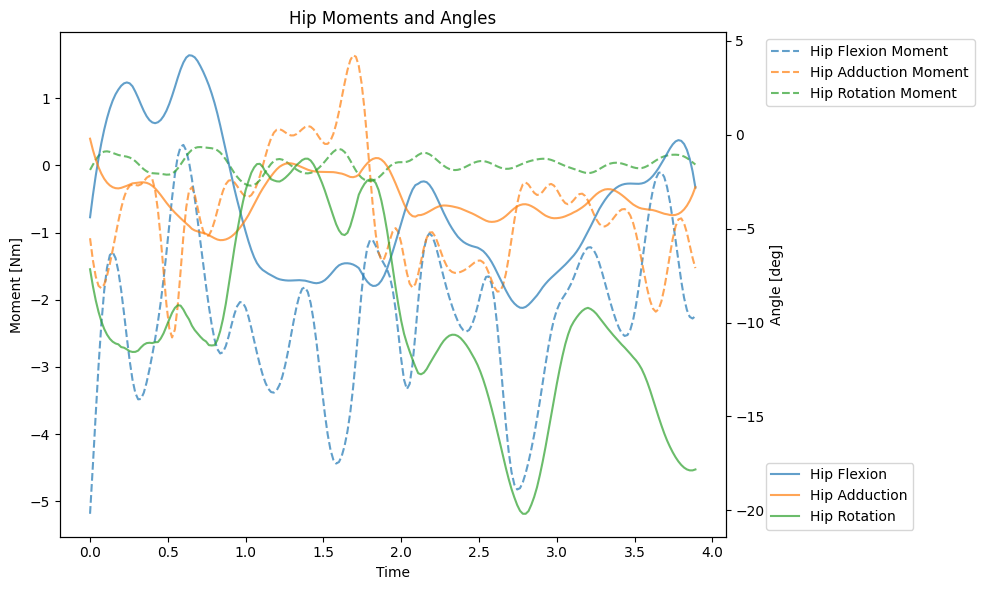

In [80]:
#| echo: false

# pick one pcn folder
samplefolder = pcnfolders[800]

ikfile = glob.glob(os.path.join(samplefolder, 'kinematics', '*smoothed*.mot'))[0]
print(ikfile)
idfile = glob.glob(os.path.join(samplefolder, 'kinematics', '*smoothed*.sto'))[0]
print(idfile)

# Load in
iddata = pd.read_csv(idfile, sep='\t', skiprows=6)
ikdata = pd.read_csv(ikfile, sep='\t', skiprows=10)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Create second y-axis
ax2 = ax1.twinx()

# Define colors for consistency
colors = {
    'Hip Flexion': 'tab:blue',
    'Hip Adduction': 'tab:orange',
    'Hip Rotation': 'tab:green'
}

# Plot moments (dashed lines) on primary y-axis
ax1.plot(iddata['time'], iddata['hip_flexion_r_moment'], label='Hip Flexion Moment', linestyle='--', color=colors['Hip Flexion'], alpha=0.7)
ax1.plot(iddata['time'], iddata['hip_adduction_r_moment'], label='Hip Adduction Moment', linestyle='--', color=colors['Hip Adduction'], alpha=0.7)
ax1.plot(iddata['time'], iddata['hip_rotation_r_moment'], label='Hip Rotation Moment', linestyle='--', color=colors['Hip Rotation'], alpha=0.7)

# Plot angles (solid lines) on secondary y-axis
ax2.plot(ikdata['time'], ikdata['hip_flexion_r'], label='Hip Flexion', linestyle='-', color=colors['Hip Flexion'], alpha=0.7)
ax2.plot(ikdata['time'], ikdata['hip_adduction_r'], label='Hip Adduction', linestyle='-', color=colors['Hip Adduction'], alpha=0.7)
ax2.plot(ikdata['time'], ikdata['hip_rotation_r'], label='Hip Rotation', linestyle='-', color=colors['Hip Rotation'], alpha=0.7)

# Labels
ax1.set_xlabel('Time')
ax1.set_ylabel('Moment [Nm]', color='black')
ax2.set_ylabel('Angle [deg]', color='black')

# Title
plt.title('Hip Moments and Angles')

# Legends
ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1))  # Adjust legend position
ax2.legend(loc='lower left', bbox_to_anchor=(1.05, 0))

# Improve layout
fig.tight_layout()

# Show plot
plt.show()


# References